In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wandb
import math

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT / "src" / "context_scaling" / "scripts"))
sys.path.insert(0, str(REPO_ROOT / "src"))

## Helpers

In [2]:
def get_wandb_table(
    tags,
    project="ideas_cv/llm-random-test",
    negative_tags=None,
    columns=None,
    print_columns=False,
):
    # WandB automatically looks for the WANDB_API_KEY environment variable.
    api = wandb.Api()

    print(f"tags: {tags}")

    if isinstance(tags, str):
        tags = [tags]

    # $and ensures the run contains ALL of the specified positive tags.
    filters = {"$and": [{"tags": tag} for tag in tags]} if tags else {}

    runs = api.runs(path=project, filters=filters)

    runs_data = []
    for run in runs:
        run_dict = {
            "sys/id": run.id,
            "sys/name": run.name,
            "sys/state": run.state,
            "sys/tags": run.tags,
        }
        run_dict.update({f"config/{k}": v for k, v in run.config.items()})
        run_dict.update({f"summary/{k}": v for k, v in run.summary._json_dict.items()})

        runs_data.append(run_dict)

    runs_table = pd.DataFrame(runs_data)

    if runs_table.empty:
        print("df shape: (0, 0)")
        return runs_table

    if columns:
        cols_to_keep = set(columns)
        if negative_tags:
            cols_to_keep.add("sys/tags")

        available_cols = [col for col in cols_to_keep if col in runs_table.columns]
        runs_table = runs_table[available_cols]

    if negative_tags:
        if isinstance(negative_tags, str):
            negative_tags = [negative_tags]

        for neg_tag in negative_tags:
            runs_table = runs_table[
                ~runs_table["sys/tags"].apply(
                    lambda x: neg_tag in x if isinstance(x, list) else False
                )
            ]

    if print_columns:
        print("\n=== Available columns ===")
        for col in sorted(runs_table.columns):
            print(f"\t{col}")
        print("========================\n")

    print(f"df shape: {runs_table.shape}")

    return runs_table


def solve_config_lr(
    config_lr: float,
) -> tuple[
    float, float
]:  # TODO temporary place - move to devinitions eval+ when created
    ret_lr, ret_exp_lr = None, None
    if config_lr < 1.0:
        ret_lr = config_lr
        ret_exp_lr = -1 * math.log(config_lr) / math.log(2)
    if config_lr >= 1.0:
        ret_lr = 2**-config_lr
        ret_exp_lr = ret_exp_lr
    return ret_lr, ret_exp_lr


def flatten_config_columns(df: pd.DataFrame, sep: str = "/") -> pd.DataFrame:
    """Expand dict-valued `config/*` columns into flat columns.

    wandb stores the nested OmegaConf config, so `run.config.items()` yields
    top-level keys like `common`, `trainer` with dict values. This walks those
    dicts and produces columns like `config/trainer/learning_rate`.
    """
    df = df.copy()

    def walk(prefix, value, out):
        if isinstance(value, dict):
            for k, v in value.items():
                walk(f"{prefix}{sep}{k}", v, out)
        else:
            out[prefix] = value

    config_cols = [c for c in df.columns if c.startswith("config/")]
    new_rows = []
    for _, row in df.iterrows():
        flat = {}
        for c in config_cols:
            walk(c, row[c], flat)
        new_rows.append(flat)

    flat_df = pd.DataFrame(new_rows, index=df.index)
    df = df.drop(columns=config_cols)
    return pd.concat([df, flat_df], axis=1)

In [3]:
def get_final_loss_values(runs_table, lr_col, loss_col, main_variables):
    rows = []
    for _, run_row in runs_table.iterrows():
        row = {
            "run_id": run_row["sys/id"],
            "lr": run_row[lr_col],
            "final_loss": run_row[loss_col],
        }
        for i, mv in enumerate(main_variables):
            row[f"grid_val_{i}"] = run_row[mv]
        rows.append(row)
    return pd.DataFrame(rows)


def plot_loss_vs_lr(
    runs_table,
    main_variables,
    lr_col="config/trainer/learning_rate",
    loss_col="summary/steps/eval/loss",
    n_steps_col="config/trainer/n_steps",
    step_col="summary/step",
    ylim=None,
    title=None,
    ax=None,
    ax_labels_font=12,
    tick_font=12,
    title_font=12,
    var_labels=None,
    color_map=None,
):
    """Plot final eval loss vs learning rate, one line per `main_variables` combo.

    Expects a wandb-style dataframe (columns prefixed `config/` and `summary/`).
    Finished runs (step+1 >= n_steps) are drawn with circles + solid lines;
    running runs are drawn with squares + dashed lines.

    `color_map`, if given, maps grid-value tuples to colors so multiple calls
    can share a consistent palette across subplots.
    """
    color_dict = {
        0: "#1f78b4", 1: "#33a02c", 2: "#e31a1c", 3: "#ff7f00",
        4: "#6a3d9a", 5: "#a65628", 6: "#000000",
    }

    required = ["sys/id", lr_col, loss_col, n_steps_col, step_col, *main_variables]
    missing = [c for c in required if c not in runs_table.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    final_loss_df = get_final_loss_values(
        runs_table, lr_col=lr_col, loss_col=loss_col, main_variables=main_variables
    )
    final_loss_df = final_loss_df[final_loss_df["final_loss"].notnull()]

    completion_map = {
        r["sys/id"]: "complete" if (r[step_col] + 1 >= r[n_steps_col]) else "running"
        for _, r in runs_table.iterrows()
    }
    final_loss_df["status"] = final_loss_df["run_id"].map(completion_map)

    grid_cols = [f"grid_val_{i}" for i in range(len(main_variables))]
    grid_val_sets = (
        final_loss_df[grid_cols]
        .drop_duplicates()
        .sort_values(grid_cols)
        .itertuples(index=False, name=None)
    )

    var_labels = var_labels or {}

    for color_num, grid_vals in enumerate(grid_val_sets):
        mask = (final_loss_df[grid_cols] == grid_vals).all(axis=1)
        subset = final_loss_df[mask]
        color = color_map.get(grid_vals) if color_map is not None else color_dict.get(color_num)

        label = ", ".join(
            f"{var_labels.get(name, name)}: {value}"
            for name, value in zip(main_variables, grid_vals)
        )

        target = ax if ax is not None else plt

        finished = subset[subset["status"] == "complete"]
        if not finished.empty:
            means = finished.sort_values("lr").groupby("lr")["final_loss"].mean()
            target.plot(means.index.to_numpy(), means.values, marker="o",
                        color=color, label=label, linestyle="-")

        running = subset[subset["status"] != "complete"]
        if not running.empty:
            means = running.sort_values("lr").groupby("lr")["final_loss"].mean()
            target.plot(means.index.to_numpy(), means.values, marker="s",
                        color=color, label=label, linestyle="--", markersize=6)

    if ax is None:
        plt.legend()
        plt.tick_params(axis="both", labelsize=tick_font)
        plt.xlabel("Learning Rate", fontsize=ax_labels_font)
        plt.ylabel("Final Eval Loss", fontsize=ax_labels_font)
        plt.title(title or "Final Loss vs Learning Rate", fontsize=title_font)
        plt.grid(True)
        plt.xscale("log", base=2)
        if ylim is not None:
            plt.ylim(ylim)
        plt.show()
    else:
        ax.legend()
        ax.set_xlabel("Learning Rate", fontsize=ax_labels_font)
        ax.set_ylabel("Final Eval Loss", fontsize=ax_labels_font)
        ax.tick_params(axis="both", labelsize=tick_font)
        ax.set_xscale("log", base=2)
        ax.set_title(title or "Final Loss vs Learning Rate", fontsize=title_font)
        ax.grid(True)
        if ylim is not None:
            ax.set_ylim(ylim)

## simpleP dense

In [4]:
tags1 = ["simpleP_dense2"]
tags2 = ["vanilla2"]
negative_tags = ["remove"]
project = "ideas_cv/llm-random-test"

def resolve_lr(df):
    # config/trainer/learning_rate is the raw config value; solve_config_lr
    # maps x>=1 to 2**-x so the axis reflects the effective LR used in training.
    df = df.copy()
    df["config/trainer/learning_rate"] = df["config/trainer/learning_rate"].apply(
        lambda x: solve_config_lr(x)[0] if pd.notnull(x) else x
    )
    return df

df_simpleP_raw = get_wandb_table(tags1, project=project, negative_tags=negative_tags)
df_simpleP_dense = resolve_lr(flatten_config_columns(df_simpleP_raw))
print("simpleP:", df_simpleP_dense.shape)

df_vanilla_raw = get_wandb_table(tags2, project=project, negative_tags=negative_tags)
df_vanilla_dense = resolve_lr(flatten_config_columns(df_vanilla_raw))
print("vanilla:", df_vanilla_dense.shape)

wandb: Currently logged in as: j321m (j321m-uniwersytet-warszawski) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


tags: ['simpleP_dense2']
df shape: (24, 610)
simpleP: (24, 804)
tags: ['vanilla2']
df shape: (63, 609)
vanilla: (63, 806)


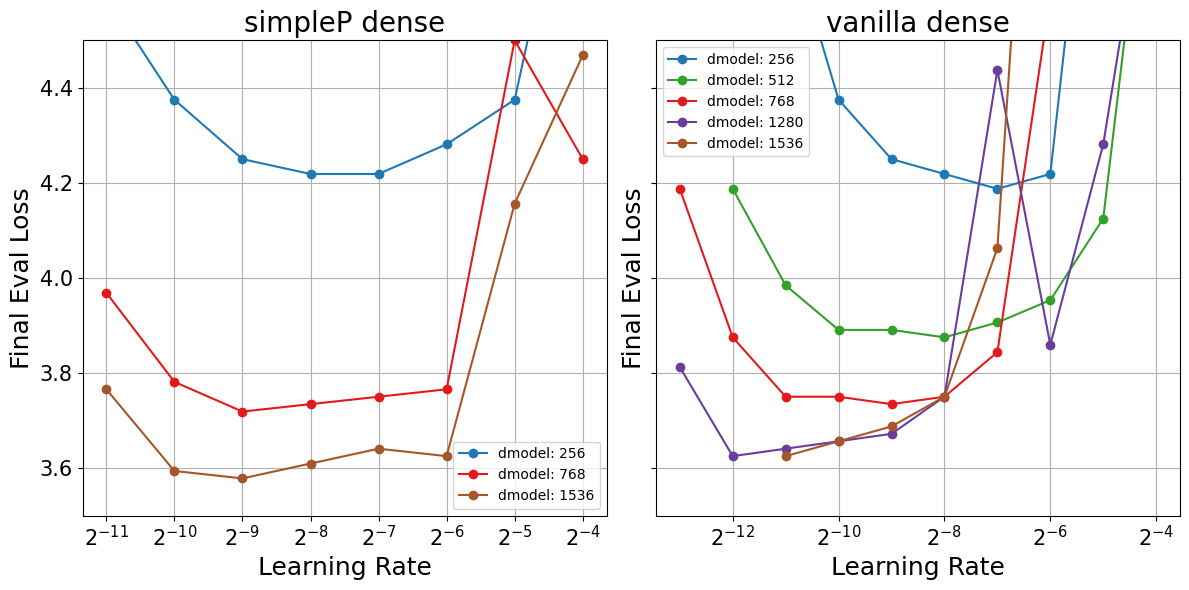

In [5]:
var_labels = {
    "config/common/dmodel": "dmodel",
}

mv = "config/common/dmodel"
all_vals = sorted(set(df_simpleP_dense[mv].dropna()) | set(df_vanilla_dense[mv].dropna()))
palette = ["#1f78b4", "#33a02c", "#e31a1c", "#ff7f00", "#6a3d9a", "#a65628", "#000000"]
color_map = {(v,): palette[i % len(palette)] for i, v in enumerate(all_vals)}
ylim=(3.5, 4.5)

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
plot_loss_vs_lr(
    df_simpleP_dense,
    main_variables=[mv],
    title="simpleP dense",
    ax=axes[0],
    ax_labels_font=18,
    tick_font=15,
    title_font=20,
    var_labels=var_labels,
    color_map=color_map,
    ylim=ylim,
)
plot_loss_vs_lr(
    df_vanilla_dense,
    main_variables=[mv],
    title="vanilla dense",
    ax=axes[1],
    ax_labels_font=18,
    tick_font=15,
    title_font=20,
    var_labels=var_labels,
    color_map=color_map,
    ylim=ylim,
)
plt.tight_layout()

### long warmup

In [21]:
tags1 = ["long_warmup", "simpleP_dense3"]
negative_tags = ["remove"]
project = "ideas_cv/llm-random-test"

def resolve_lr(df):
    # config/trainer/learning_rate is the raw config value; solve_config_lr
    # maps x>=1 to 2**-x so the axis reflects the effective LR used in training.
    df = df.copy()
    df["config/trainer/learning_rate"] = df["config/trainer/learning_rate"].apply(
        lambda x: solve_config_lr(x)[0] if pd.notnull(x) else x
    )
    return df

df_simpleP_raw = get_wandb_table(tags1, project=project, negative_tags=negative_tags)
df_simpleP_dense_long_warmup = resolve_lr(flatten_config_columns(df_simpleP_raw))
print("simpleP:", df_simpleP_dense_long_warmup.shape)


tags: ['long_warmup', 'simpleP_dense3']
df shape: (8, 610)
simpleP: (8, 804)


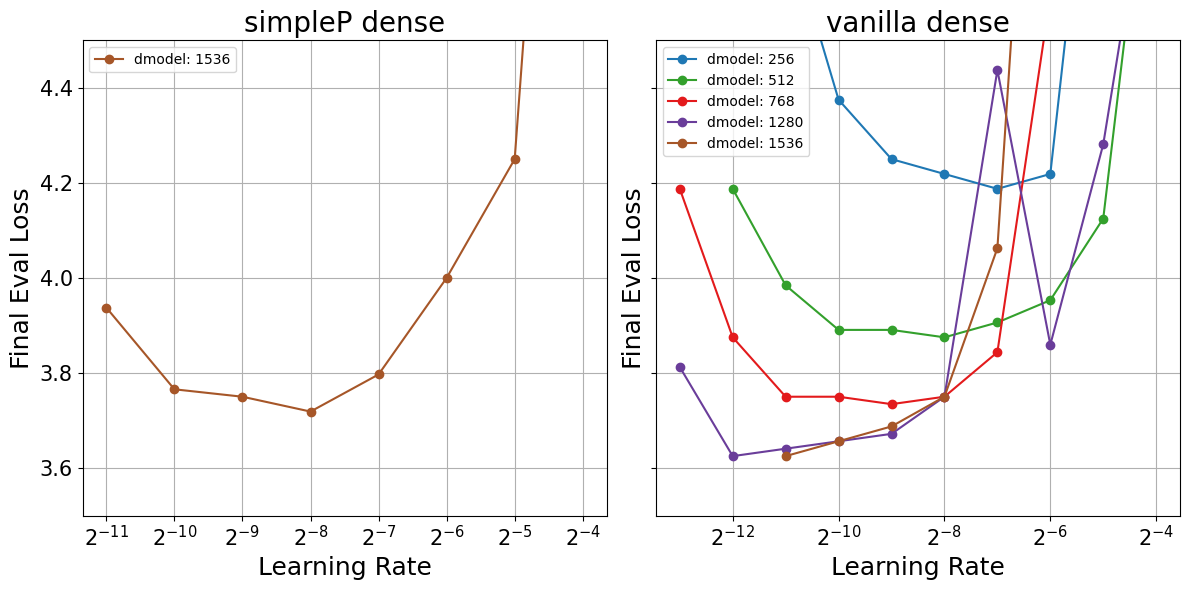

In [22]:
var_labels = {
    "config/common/dmodel": "dmodel",
}

mv = "config/common/dmodel"
all_vals = sorted(set(df_simpleP_dense_long_warmup[mv].dropna()) | set(df_vanilla_dense[mv].dropna()))
palette = ["#1f78b4", "#33a02c", "#e31a1c", "#ff7f00", "#6a3d9a", "#a65628", "#000000"]
color_map = {(v,): palette[i % len(palette)] for i, v in enumerate(all_vals)}
ylim=(3.5, 4.5)

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
plot_loss_vs_lr(
    df_simpleP_dense_long_warmup,
    main_variables=[mv],
    title="simpleP dense",
    ax=axes[0],
    ax_labels_font=18,
    tick_font=15,
    title_font=20,
    var_labels=var_labels,
    color_map=color_map,
    ylim=ylim,
)
plot_loss_vs_lr(
    df_vanilla_dense,
    main_variables=[mv],
    title="vanilla dense",
    ax=axes[1],
    ax_labels_font=18,
    tick_font=15,
    title_font=20,
    var_labels=var_labels,
    color_map=color_map,
    ylim=ylim,
)
plt.tight_layout()

## simpleP MoE

In [17]:
tags1 = ["simpleP_moe2"]
tags2 = ["vanilla_moe2"]
negative_tags = ["remove"]
project = "ideas_cv/llm-random-test"

def resolve_lr(df):
    # config/trainer/learning_rate is the raw config value; solve_config_lr
    # maps x>=1 to 2**-x so the axis reflects the effective LR used in training.
    df = df.copy()
    df["config/trainer/learning_rate"] = df["config/trainer/learning_rate"].apply(
        lambda x: solve_config_lr(x)[0] if pd.notnull(x) else x
    )
    return df

df_simpleP_raw = get_wandb_table(tags1, project=project, negative_tags=negative_tags)
df_simpleP_moe = resolve_lr(flatten_config_columns(df_simpleP_raw))
print("simpleP:", df_simpleP_moe.shape)

df_vanilla_raw = get_wandb_table(tags2, project=project, negative_tags=negative_tags)
df_vanilla_moe = resolve_lr(flatten_config_columns(df_vanilla_raw))
print("vanilla:", df_vanilla_moe.shape)

tags: ['simpleP_moe2']
df shape: (24, 618)
simpleP: (24, 800)
tags: ['vanilla_moe2']
df shape: (24, 617)
vanilla: (24, 799)


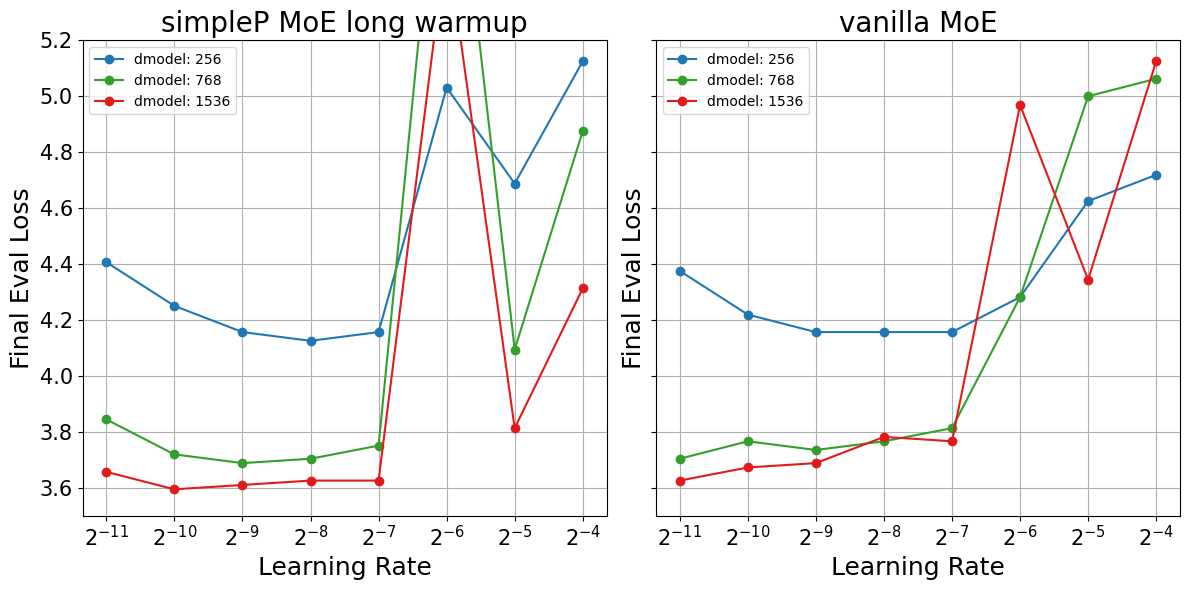

In [18]:
var_labels = {
    "config/common/dmodel": "dmodel",
}

mv = "config/common/dmodel"
all_vals = sorted(set(df_simpleP_moe[mv].dropna()) | set(df_vanilla_moe[mv].dropna()))
palette = ["#1f78b4", "#33a02c", "#e31a1c", "#ff7f00", "#6a3d9a", "#a65628", "#000000"]
color_map = {(v,): palette[i % len(palette)] for i, v in enumerate(all_vals)}
ylim = (3.5, 5.2)

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
plot_loss_vs_lr(
    df_simpleP_moe,
    main_variables=[mv],
    title="simpleP MoE long warmup",
    ax=axes[0],
    ax_labels_font=18,
    tick_font=15,
    title_font=20,
    var_labels=var_labels,
    color_map=color_map,
    ylim=ylim,
)
plot_loss_vs_lr(
    df_vanilla_moe,
    main_variables=[mv],
    title="vanilla MoE",
    ax=axes[1],
    ax_labels_font=18,
    tick_font=15,
    title_font=20,
    var_labels=var_labels,
    color_map=color_map,
    ylim=ylim,
)
plt.tight_layout()

### long warmup

In [19]:
tags1 = ["long_warmup", "simpleP_moe"]
negative_tags = ["remove"]
project = "ideas_cv/llm-random-test"

def resolve_lr(df):
    # config/trainer/learning_rate is the raw config value; solve_config_lr
    # maps x>=1 to 2**-x so the axis reflects the effective LR used in training.
    df = df.copy()
    df["config/trainer/learning_rate"] = df["config/trainer/learning_rate"].apply(
        lambda x: solve_config_lr(x)[0] if pd.notnull(x) else x
    )
    return df

df_simpleP_raw = get_wandb_table(tags1, project=project, negative_tags=negative_tags)
df_simpleP_moe_long_warmup = resolve_lr(flatten_config_columns(df_simpleP_raw))
print("simpleP:", df_simpleP_moe_long_warmup.shape)


tags: ['long_warmup', 'simpleP_moe']
df shape: (8, 618)
simpleP: (8, 800)


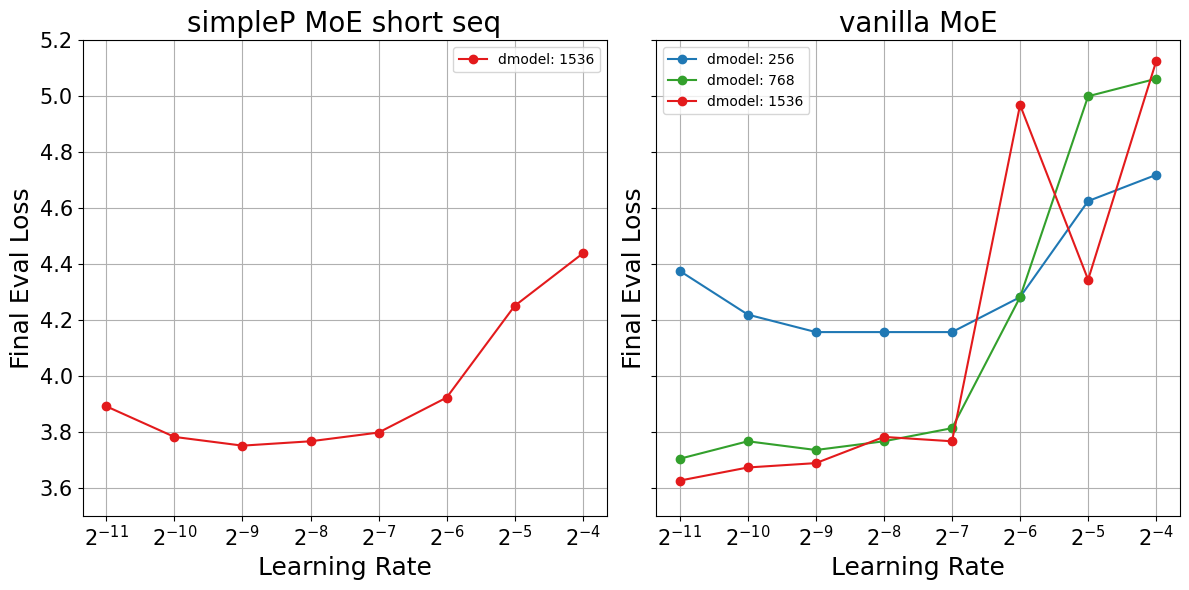

In [20]:
var_labels = {
    "config/common/dmodel": "dmodel",
}

mv = "config/common/dmodel"
all_vals = sorted(set(df_simpleP_moe_long_warmup[mv].dropna()) | set(df_vanilla_moe[mv].dropna()))
palette = ["#1f78b4", "#33a02c", "#e31a1c", "#ff7f00", "#6a3d9a", "#a65628", "#000000"]
color_map = {(v,): palette[i % len(palette)] for i, v in enumerate(all_vals)}
ylim = (3.5, 5.2)

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
plot_loss_vs_lr(
    df_simpleP_moe_long_warmup,
    main_variables=[mv],
    title="simpleP MoE short seq",
    ax=axes[0],
    ax_labels_font=18,
    tick_font=15,
    title_font=20,
    var_labels=var_labels,
    color_map=color_map,
    ylim=ylim,
)
plot_loss_vs_lr(
    df_vanilla_moe,
    main_variables=[mv],
    title="vanilla MoE",
    ax=axes[1],
    ax_labels_font=18,
    tick_font=15,
    title_font=20,
    var_labels=var_labels,
    color_map=color_map,
    ylim=ylim,
)
plt.tight_layout()

### short seq

In [10]:
tags1 = ["short_seq", "simpleP_moe"]
negative_tags = ["remove"]
project = "ideas_cv/llm-random-test"

def resolve_lr(df):
    # config/trainer/learning_rate is the raw config value; solve_config_lr
    # maps x>=1 to 2**-x so the axis reflects the effective LR used in training.
    df = df.copy()
    df["config/trainer/learning_rate"] = df["config/trainer/learning_rate"].apply(
        lambda x: solve_config_lr(x)[0] if pd.notnull(x) else x
    )
    return df

df_simpleP_raw = get_wandb_table(tags1, project=project, negative_tags=negative_tags)
df_simpleP_moe_short_seq = resolve_lr(flatten_config_columns(df_simpleP_raw))
print("simpleP:", df_simpleP_moe_short_seq.shape)


tags: ['short_seq', 'simpleP_moe']
df shape: (7, 618)
simpleP: (7, 800)


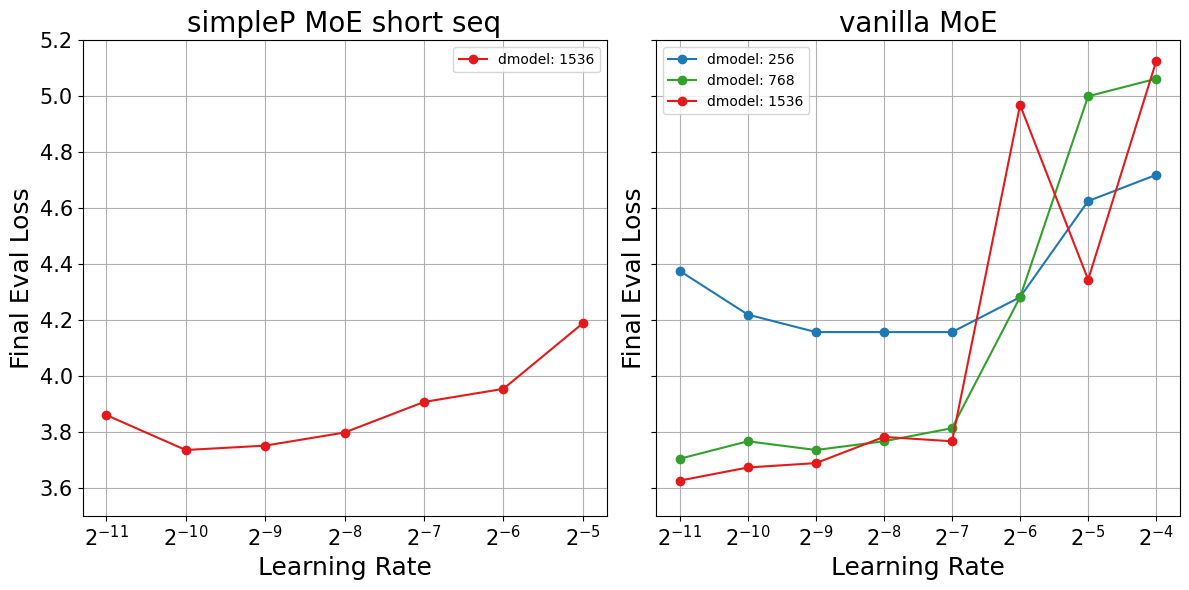

In [11]:
var_labels = {
    "config/common/dmodel": "dmodel",
}

mv = "config/common/dmodel"
all_vals = sorted(set(df_simpleP_moe_short_seq[mv].dropna()) | set(df_vanilla_moe[mv].dropna()))
palette = ["#1f78b4", "#33a02c", "#e31a1c", "#ff7f00", "#6a3d9a", "#a65628", "#000000"]
color_map = {(v,): palette[i % len(palette)] for i, v in enumerate(all_vals)}
ylim = (3.5, 5.2)

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
plot_loss_vs_lr(
    df_simpleP_moe_short_seq,
    main_variables=[mv],
    title="simpleP MoE short seq",
    ax=axes[0],
    ax_labels_font=18,
    tick_font=15,
    title_font=20,
    var_labels=var_labels,
    color_map=color_map,
    ylim=ylim,
)
plot_loss_vs_lr(
    df_vanilla_moe,
    main_variables=[mv],
    title="vanilla MoE",
    ax=axes[1],
    ax_labels_font=18,
    tick_font=15,
    title_font=20,
    var_labels=var_labels,
    color_map=color_map,
    ylim=ylim,
)
plt.tight_layout()

### 1B tokens

In [14]:
tags1 = ["1B", "simpleP_moe"]
negative_tags = ["remove"]
project = "ideas_cv/llm-random-test"

def resolve_lr(df):
    # config/trainer/learning_rate is the raw config value; solve_config_lr
    # maps x>=1 to 2**-x so the axis reflects the effective LR used in training.
    df = df.copy()
    df["config/trainer/learning_rate"] = df["config/trainer/learning_rate"].apply(
        lambda x: solve_config_lr(x)[0] if pd.notnull(x) else x
    )
    return df

df_simpleP_raw = get_wandb_table(tags1, project=project, negative_tags=negative_tags)
df_simpleP_moe_1B = resolve_lr(flatten_config_columns(df_simpleP_raw))
print("simpleP:", df_simpleP_moe_1B.shape)


tags: ['1B', 'simpleP_moe']
df shape: (7, 618)
simpleP: (7, 800)


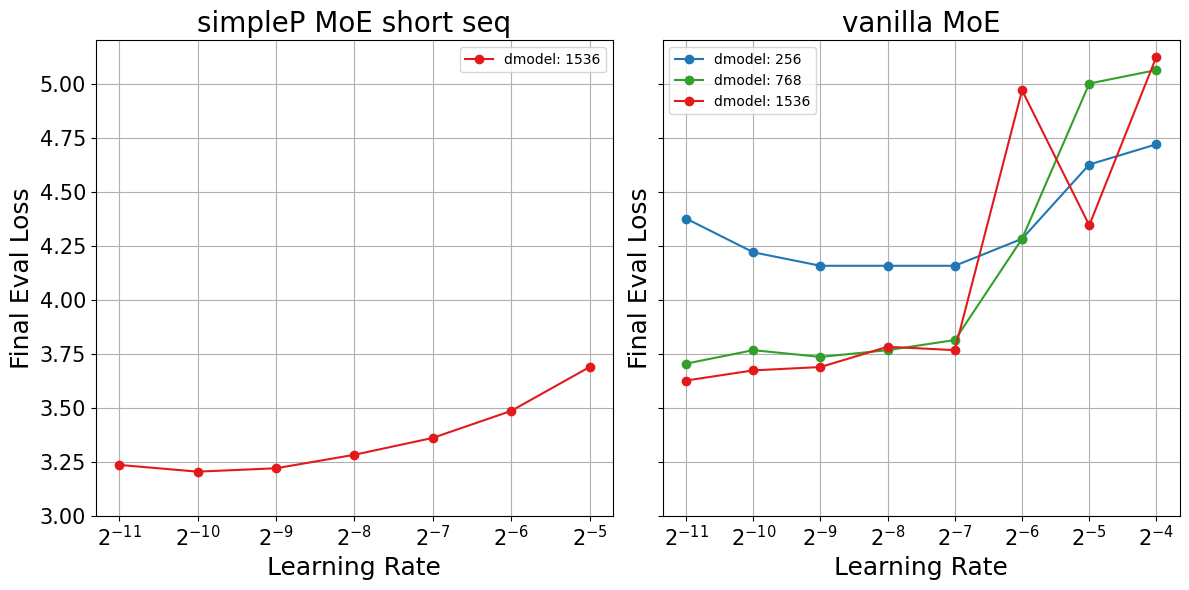

In [16]:
var_labels = {
    "config/common/dmodel": "dmodel",
}

mv = "config/common/dmodel"
all_vals = sorted(set(df_simpleP_moe_1B[mv].dropna()) | set(df_vanilla_moe[mv].dropna()))
palette = ["#1f78b4", "#33a02c", "#e31a1c", "#ff7f00", "#6a3d9a", "#a65628", "#000000"]
color_map = {(v,): palette[i % len(palette)] for i, v in enumerate(all_vals)}
ylim = (3.0, 5.2)

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
plot_loss_vs_lr(
    df_simpleP_moe_1B,
    main_variables=[mv],
    title="simpleP MoE short seq",
    ax=axes[0],
    ax_labels_font=18,
    tick_font=15,
    title_font=20,
    var_labels=var_labels,
    color_map=color_map,
    ylim=ylim,
)
plot_loss_vs_lr(
    df_vanilla_moe,
    main_variables=[mv],
    title="vanilla MoE",
    ax=axes[1],
    ax_labels_font=18,
    tick_font=15,
    title_font=20,
    var_labels=var_labels,
    color_map=color_map,
    ylim=ylim,
)
plt.tight_layout()

### PK grid

In [ ]:
df_pkgrid_raw = get_wandb_table(["2026.04.19"], project="ideas_cv/tml-bgw", negative_tags=['No_QKNorm'])
df_pkgrid = resolve_lr(flatten_config_columns(df_pkgrid_raw))
print("simpleP_bsgrid:", df_pkgrid.shape)

tags: ['2026.04.19']
df shape: (12, 423)
simpleP_bsgrid: (12, 598)


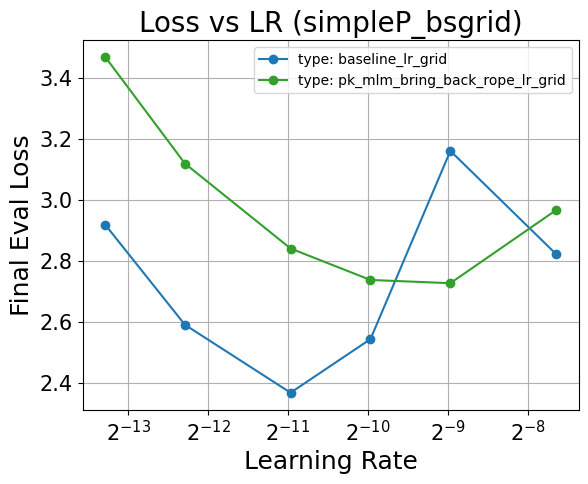

In [ ]:
var_labels_bs = {"config/infrastructure/metric_logger/name": "type"}

plot_loss_vs_lr(
    df_pkgrid,
    main_variables=["config/infrastructure/metric_logger/name"],
    title="Loss vs LR (simpleP_bsgrid)",
    ax_labels_font=18,
    tick_font=15,
    title_font=20,
    var_labels=var_labels_bs,
)